In [34]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
os.chdir('/Users/stacyli/savio/global/scratch/stacy-l/spermSV/notebooks/jupyter/20231113')
import gff_utils as gff_utils
os.chdir('/Users/stacyli/savio/global/scratch/stacy-l/spermSV')

sns.set_style('white')

# hg38 analysis

## AluY* subfamily

In [35]:
# save GFFs & create master table for plotting

samples_annotated = dict()
for sample in ['894', '895', '898', '901']:
    sample_aluY = gff_utils.annotate_gff(f'output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.vcf.gz', f'output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.alt.fa.out.gff', motif = 'AluY')
    sample_aluY['origin'] = sample
    # sample_gff3 = gff_utils.save_gff3(f'notebooks/jupyter/20231113/{sample}_aluY_hg38.gff', sample_aluY, return_df = False)
    samples_annotated[sample] = sample_aluY

AluY_samples = pd.concat([samples_annotated['894'], samples_annotated['895'], samples_annotated['898'], samples_annotated['901']])

Text(0.5, 0.98, 'AluY* subfamily\nread distribution')

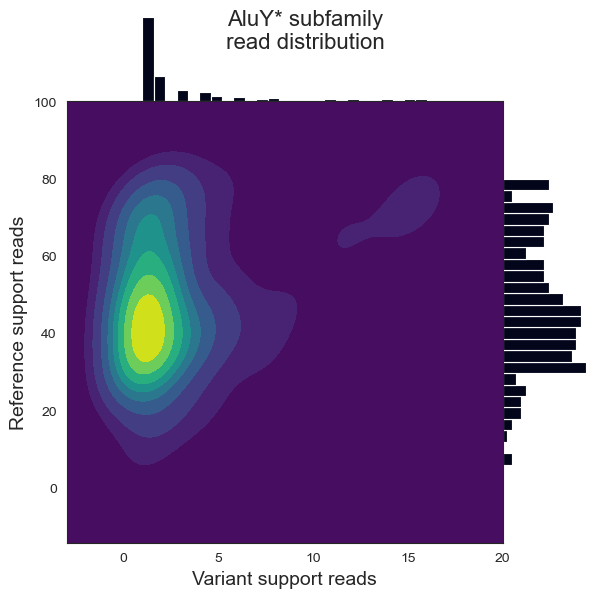

In [21]:
# use viz limits to determine the cutoff vals for filtering

g = sns.JointGrid(data=AluY_samples.query("ref_reads <= 80"), x="alt_reads", y="ref_reads", space=0)
g.plot_joint(sns.kdeplot, fill=True, thresh=0, cmap="viridis",)
g.plot_marginals(sns.histplot, color="#03051A", alpha=1, bins=25)
g.set_axis_labels(xlabel = "Variant support reads", ylabel = "Reference support reads", size = 14)
plt.suptitle("AluY* subfamily\nread distribution", size = 16)

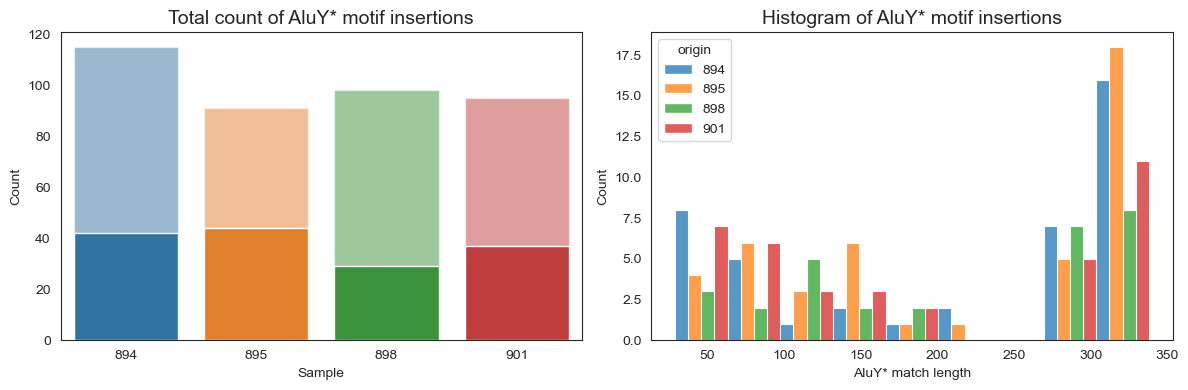

In [11]:
# Figure modified to show "cut down" of calls with filtering to exclude ambiguous chr placements and rough limiting of ref/alt counts
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))
axes = axes.flatten()

sns.countplot(ax = axes[0], data = AluY_samples, x = 'origin', hue = 'origin', alpha = 0.5)
sns.countplot(ax = axes[0], data = AluY_samples[~AluY_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'origin', hue = 'origin')
axes[0].set_title("Total count of AluY* motif insertions", size = 14)
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Count")

sns.histplot(ax = axes[1], data = AluY_samples[~AluY_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'match_len', hue = 'origin', multiple="dodge")
axes[1].set_title("Histogram of AluY* motif insertions", size = 14)
axes[1].set_xlabel("AluY* match length")
axes[1].set_ylabel("Count")

plt.tight_layout()

In [31]:
for sample in ['894', '895', '898', '901']:
    # export for bam filtering
    gff_utils.rnames_to_txt(f'notebooks/jupyter/20231113/{sample}_aluY_hg38.txt', AluY_samples.query(f"origin == {sample} & ref_reads <= 80 & alt_reads <= 10"))
    # save to csv for markup
    AluY_samples.query(f"origin == {sample} & ref_reads <= 80 & alt_reads <= 10").to_csv(f'notebooks/jupyter/20231113/{sample}_aluY_hg38.csv')

Saving .txt file to notebooks/jupyter/20231113/895_aluY_hg38.txt ...


In [122]:
# read in super duper annotated files...

samples_annotated = dict()
for sample in ['894', '895', '898', '901']:
    samples_annotated[sample]= pd.read_csv(f'notebooks/jupyter/20231113/{sample}_aluY_hg38.csv', index_col = 0, encoding = 'latin-1')

AluY_samples = pd.concat(samples_annotated.values()).reset_index(drop = True)
AluY_samples.to_csv('notebooks/jupyter/20231113/all_aluY_hg38.csv')

# drop variants on random* ctgs for plotting below
AluY_samples = AluY_samples[~AluY_samples['#CHROM'].str.contains('_')]

# annotate chromosome type
AluY_samples['chrom_type'] = 

In [125]:
chrom_morph = {'chr1': 'metacentric',
              'chr2': 'submetacentric',
              'chr3': 'metacentric',
              'chr4': 'submetacentric',
              'chr5': 'submetacentric',
              'chr6': 'submetacentric',
              'chr7': 'submetacentric',
              'chr8': 'submetacentric',
              'chr10': 'submetacentric',
              'chr11': 'submetacentric',
              'chr12': 'submetacentric',
              'chr13': 'acrocentric',
              'chr14': 'acrocentric',
              'chr15': 'acrocentric',
              'chr16': 'metacentric',
              'chr17': 'submetacentric',
              'chr18': 'submetacentric',
              'chr19': 'metacentric',
              'chr20': 'metacentric',
              'chr21': 'acrocentric',
              'chr22': 'acrocentric',
              'chrX': 'submetacentric',
              'chrY': 'acrocentric'}

In [72]:
AluY_samples.columns

Index(['ID', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame',
       'attribute', 'motif', 'match_len', 'SVLEN', '#CHROM', 'POS', 'REF',
       'ALT', 'ref_reads', 'alt_reads', 'RNAMES', 'origin', 'arm', 'location',
       'feature?', 'protein coding?', 'PLI (gnomAD)', 'description', 'other'],
      dtype='object')

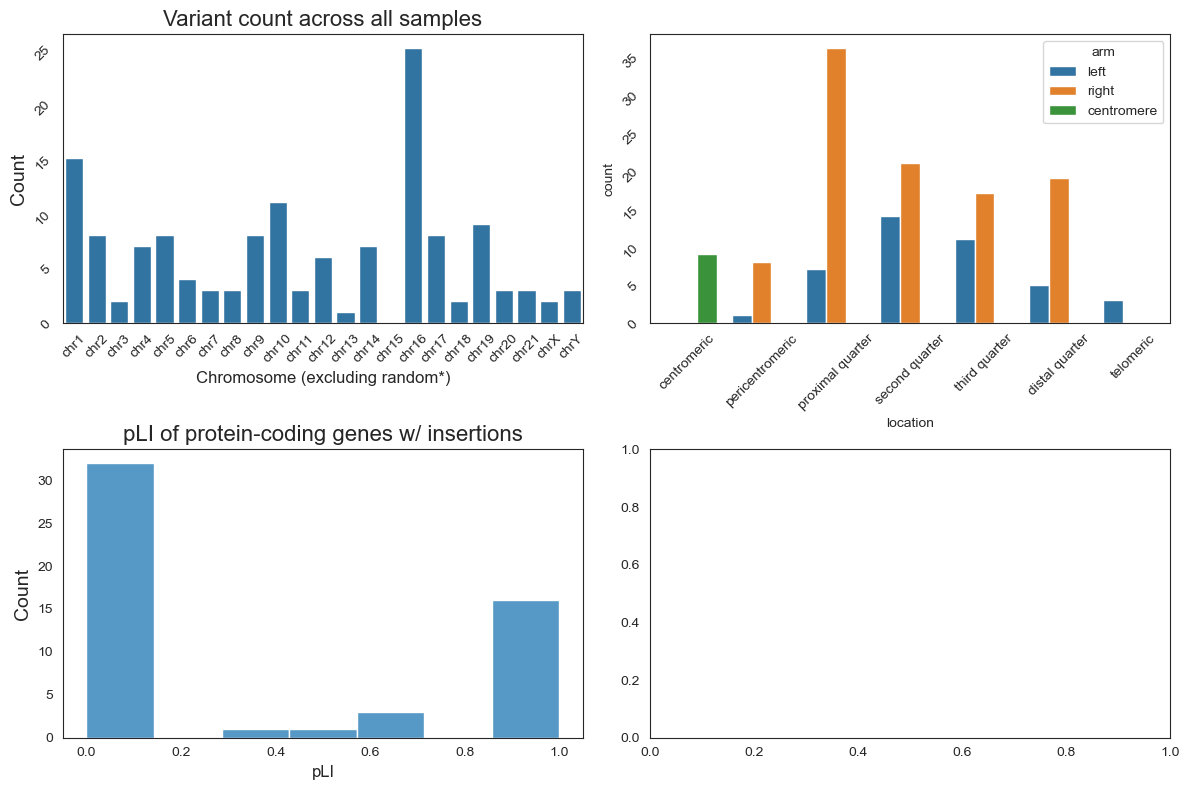

In [123]:
# note that these figures exclude variants on random* ctgs, as filtered above

fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 8))
axes = axes.flatten()

sns.countplot(ax = axes[0], data = AluY_samples, x = '#CHROM',
            order = ['chr{n}'.format(n = chrom) for chrom in list(np.arange(1,22)) + ['X', 'Y']])
axes[0].tick_params(labelrotation = 45)
axes[0].set_title("Variant count across all samples", size = 16)
axes[0].set_ylabel("Count", size = 14)
axes[0].set_xlabel("Chromosome (excluding random*)", size = 12)

sns.countplot(ax = axes[1], data = AluY_samples, x = 'location', hue = 'arm',
            order = ['centromeric', 'pericentromeric', 'proximal quarter', 'second quarter', 'third quarter', 'distal quarter', 'telomeric'])
axes[1].tick_params(labelrotation = 45)

sns.histplot(ax = axes[2], data = AluY_samples, x = 'PLI (gnomAD)')
axes[2].set_title("pLI of protein-coding genes w/ insertions", size = 16)
axes[2].set_ylabel("Count", size = 14)
axes[2].set_xlabel("pLI", size = 12)

plt.tight_layout()

<Axes: xlabel='#CHROM'>

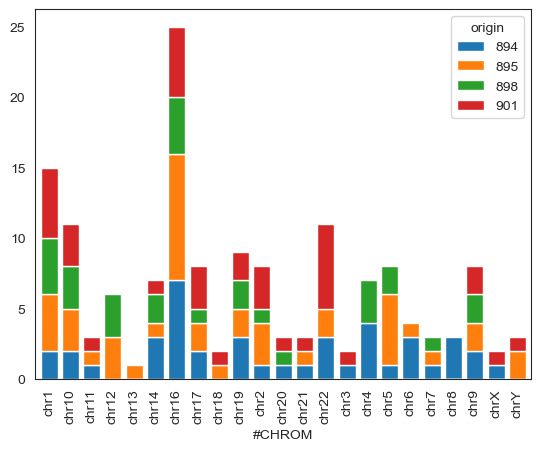

In [110]:
# stacked barplot version
# https://stackoverflow.com/questions/50319614/count-plot-with-stacked-bars-per-hue

AluY_samples.groupby(['#CHROM', 'origin']).size().reset_index().pivot(columns = 'origin', index = '#CHROM', values = 0).plot(kind = 'bar', stacked = True, width = 0.8)

## SVA family

Quickly repeating last week's Alu analysis with a different family of active elements.

In [36]:
# save GFFs & create master table for plotting

samples_annotated = dict()
for sample in ['894', '895', '898', '901']:
    sample_SVA = gff_utils.annotate_gff(f'output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.vcf.gz', f'output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.alt.fa.out.gff', motif = 'SVA')
    sample_SVA['origin'] = sample
    # sample_gff3 = gff_utils.save_gff3(f'notebooks/jupyter/20231113/{sample}_SVA_hg38.gff', sample_SVA, return_df = False)
    samples_annotated[sample] = sample_SVA

SVA_samples = pd.concat([samples_annotated['894'], samples_annotated['895'], samples_annotated['898'], samples_annotated['901']])

Text(0.5, 0.98, 'SVA* family\nread distribution')

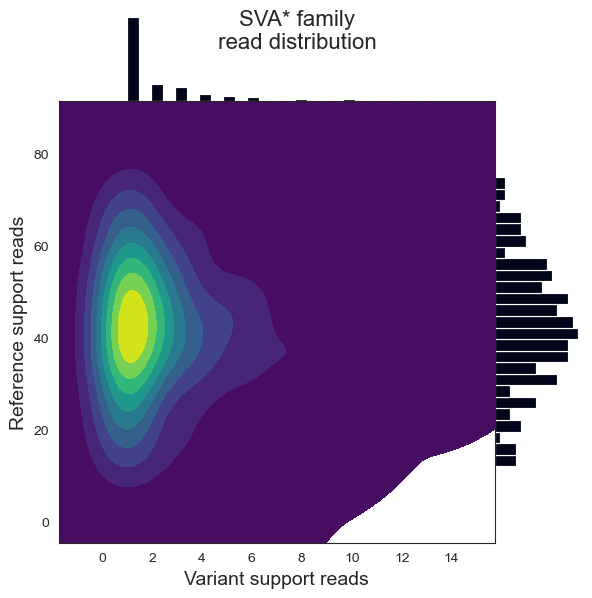

In [20]:
# use viz limits to determine the cutoff vals for filtering

g = sns.JointGrid(data=SVA_samples.query("ref_reads <= 80"), x="alt_reads", y="ref_reads", space=0)
g.plot_joint(sns.kdeplot, fill=True, thresh=0, cmap="viridis",)
g.plot_marginals(sns.histplot, color="#03051A", alpha=1, bins=25)
g.set_axis_labels(xlabel = "Variant support reads", ylabel = "Reference support reads", size = 14)
plt.suptitle("SVA* family\nread distribution", size = 16)

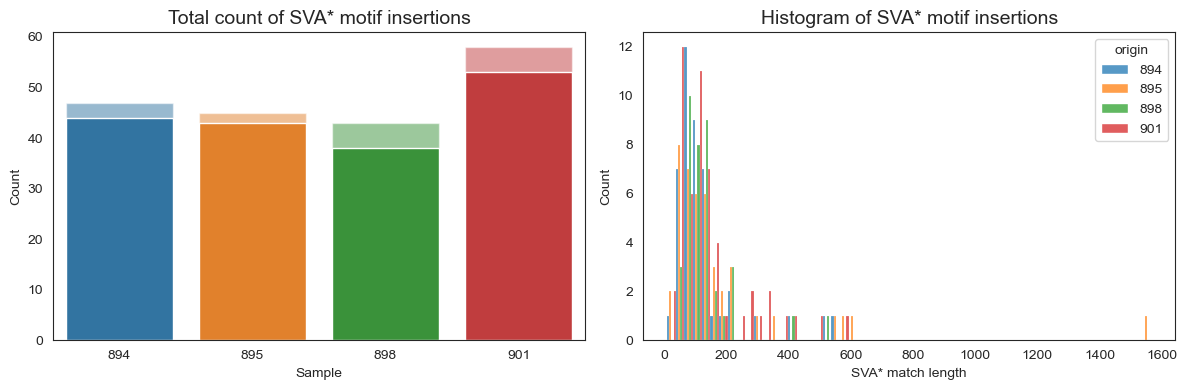

In [22]:
# Figure modified to show "cut down" of calls with filtering to exclude ambiguous chr placements and rough limiting of ref/alt counts
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))
axes = axes.flatten()

sns.countplot(ax = axes[0], data = SVA_samples, x = 'origin', hue = 'origin', alpha = 0.5)
sns.countplot(ax = axes[0], data = SVA_samples[~SVA_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'origin', hue = 'origin')
axes[0].set_title("Total count of SVA* motif insertions", size = 14)
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Count")

sns.histplot(ax = axes[1], data = SVA_samples[~SVA_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'match_len', hue = 'origin', multiple="dodge")
axes[1].set_title("Histogram of SVA* motif insertions", size = 14)
axes[1].set_xlabel("SVA* match length")
axes[1].set_ylabel("Count")

plt.tight_layout()

In [49]:
SVA_samples.sort_values('match_len', ascending = False).head().iloc[0]['ALT']

'AAGAAGGAGCTGTCTTCGCCCCGTCCGGGAGGTGAGGGGCGCCTCTGCCCGGCCGCCCCTACTGGGAAGTGAGGAGCCCCTCAGCCCGGCCAGCCACCCCGTCCGGGAGGGAGATGGGGGGTCAGCCCCCCCACCCGGCCAGCCGCCCCGTCCGGTAGGGAGGTAGGGGGGTCAGCCCCCCGCCTGCCCAGCCGCCCCTACTGGGAAGTGAGGAGCCCTTCTGCCCGGCCAGCCGCCCCGTCCGGGAGGGAGGTGGGGGGGTCAGCCCCCCGCCCGGCCAGCTGCCCTGTCCGGGAGGGAGGTGGGGGGGTCAGCACTCCGCCCGGCCAGCCGCCCCGTCTGGGAGGTGAGGGGCGCCTCTGCCCGGCCGCCCCTACTGGGAAGTGAGGAGCCCCTCTGCCCGGCCAGCCGCCCCATCCGGGAGGGAGGTGGGGGGGTCGGCCCCCCGCCCGGCCAGCCGCCCCGTCCGGGAGAGAGGTGGGGGGGTCGGCCCCCCGCCCGGCCAGCCGCCCCATCCCGGAGGGAGGTGGGGGGGGGTCGGCCCCCCTGCCCGGCCAGCCGCCCCGTCCGGGAGGTGAGGGGCGCCTCTGCCCGGCCGCCCCTACTGGGAAGTGAGGAGCCCCTCTGCCCGGCCAGCCGCCCCGTCCGGGAGGGAGGTGGGGGGGTCGGCCCCCCGCCCGGCCAGCCGCCCCGTCCGGGAGGGAGGTGGGGGGTCGGCCCCCCGCCCGGCCAGCCGCCCCGTCCGGGAGGGAGGTGGGGTGTCGGCCCCCCGCCCGGCCAGCCGCCCTGTCCGGGAGGGAGGTGGGGGGGTGTCGGCCCCCCTGCCCGGCCAGCCGCCCCGTCCGGGAGGTGAGGGGCGCCTCTGCCCGGCCGCCCCTACTGGGAAGTGAGGAGCCCCTCTGCCCGGCCAGCCGCCCCGTCCGGGAGGGAGGTGGGGGGGGGGGTCAGCCCCCCCGCCCAGCCAGCCGCCCTGTCCGGGAGGTGAGGGGCGCCTCTGCC

## L1 family

Same as above.

In [37]:
# save GFFs & create master table for plotting

samples_annotated = dict()
for sample in ['894', '895', '898', '901']:
    sample_L1 = gff_utils.annotate_gff(f'output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.vcf.gz', f'output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.alt.fa.out.gff', motif = 'L1')
    sample_L1['origin'] = sample
    # sample_gff3 = gff_utils.save_gff3(f'notebooks/jupyter/20231113/{sample}_L1_hg38.gff', sample_SVA, return_df = False)
    samples_annotated[sample] = sample_L1

L1_samples = pd.concat([samples_annotated['894'], samples_annotated['895'], samples_annotated['898'], samples_annotated['901']])

Text(0.5, 0.98, 'L1* family\nread distribution')

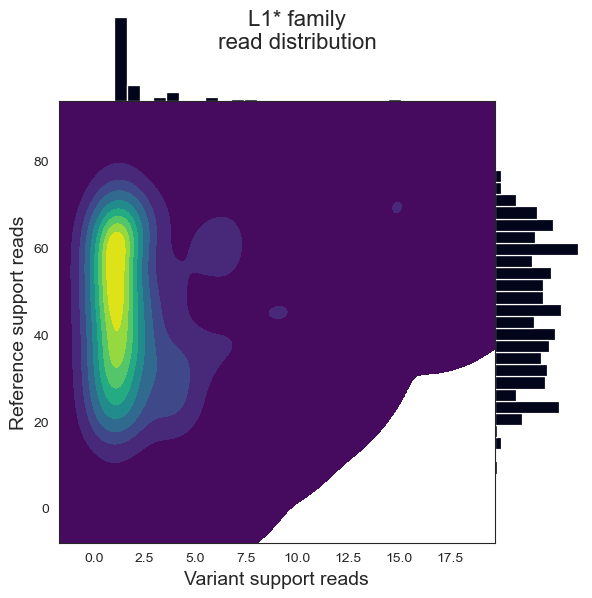

In [39]:
g = sns.JointGrid(data=L1_samples.query("ref_reads <= 80"), x="alt_reads", y="ref_reads", space=0)
g.plot_joint(sns.kdeplot, fill=True, thresh=0, cmap="viridis",)
g.plot_marginals(sns.histplot, color="#03051A", alpha=1, bins=25)
g.set_axis_labels(xlabel = "Variant support reads", ylabel = "Reference support reads", size = 14)
plt.suptitle("L1* family\nread distribution", size = 16)

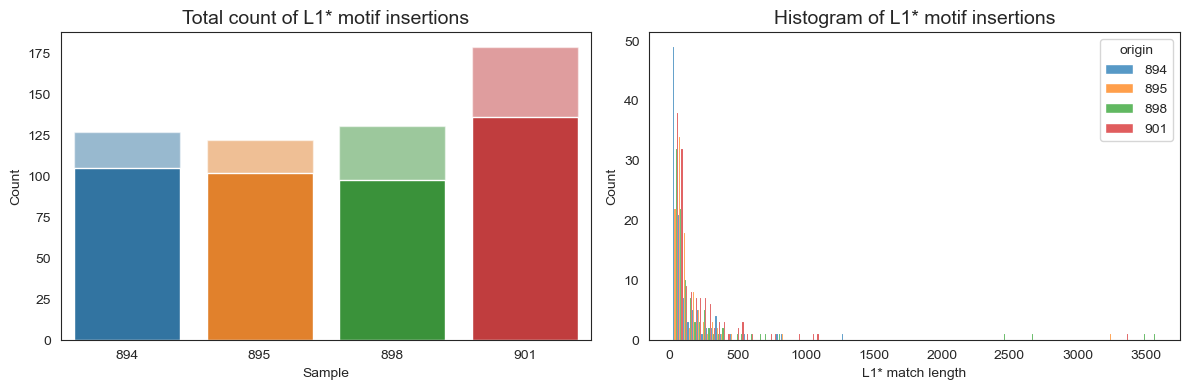

In [40]:
# Figure modified to show "cut down" of calls with filtering to exclude ambiguous chr placements and rough limiting of ref/alt counts
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))
axes = axes.flatten()

sns.countplot(ax = axes[0], data = L1_samples, x = 'origin', hue = 'origin', alpha = 0.5)
sns.countplot(ax = axes[0], data = L1_samples[~L1_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'origin', hue = 'origin')
axes[0].set_title("Total count of L1* motif insertions", size = 14)
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Count")

sns.histplot(ax = axes[1], data = L1_samples[~L1_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'match_len', hue = 'origin', multiple="dodge")
axes[1].set_title("Histogram of L1* motif insertions", size = 14)
axes[1].set_xlabel("L1* match length")
axes[1].set_ylabel("Count")

plt.tight_layout()